# Joint Detection of AI-Generated Images and Post-Processing Alterations
**Course**: Computer Vision - Prof. Irene Amerini, Sapienza Spring 2026
**Team**: Mahnoor · Naveen · Rayen
**Dataset**: RRDataset (Li et al., ICCV 2025)



In [ ]:

import sys

IS_COLAB = 'google.colab' in sys.modules

if IS_COLAB:
    import subprocess
    pkgs = ['timm', 'transformers', 'scikit-learn', 'pandas', 'tqdm']
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs, check=True)


In [ ]:
# main imports - keeping a few extra ones here because I used them while testing
import math
import copy
# imports
import os
import csv
import json
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

from pathlib import Path
from PIL import Image
from tqdm import tqdm
from collections import defaultdict, Counter, deque

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim import AdamW, SGD
from torch.optim.lr_scheduler import CosineAnnealingLR

from torchvision import transforms
import timm

from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

try:
    from transformers import AutoModel
except ImportError:
    AutoModel = None


In [ ]:
# paths
IS_COLAB = 'google.colab' in sys.modules

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATASET_ROOT = '/content/drive/MyDrive/CV/extracted'
else:
    DATASET_ROOT = '/Users/naveen/Downloads/masters_sapienza_notes/semester2/CV/dataset'

print(f'DATASET_ROOT = {DATASET_ROOT}')


DATASET_ROOT = /Users/naveen/Downloads/masters_sapienza_notes/semester2/CV/dataset


In [ ]:
# project values kept separately so it is easier for me to change them later
# globals
SEED = 42
RANDOM_SEED = 42
NUMPY_SEED = 42
TORCH_SEED = 42

RRDATASET_FINAL = os.path.join(DATASET_ROOT, 'RRDataset_final')
RRDATASET_ORIGINAL = os.path.join(DATASET_ROOT, 'RRDataset_original_train_val')

TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

REALFAKE_LABELS = {'real': 0, 'ai': 1}
TRANSFORM_LABELS = {'original': 0, 'transfer': 1, 'redigital': 2}
REALFAKE_NAMES = {0: 'real', 1: 'ai'}
TRANSFORM_NAMES = {0: 'original', 1: 'transfer', 2: 'redigital'}

NUM_REALFAKE_CLASSES = 2
NUM_TRANSFORM_CLASSES = 3

IMG_SIZE = 224

if IS_COLAB:
    BATCH_SIZE = 64
    NUM_WORKERS = 4
else:
    BATCH_SIZE = 32
    NUM_WORKERS = 0

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 15
WARMUP_EPOCHS = 3
DROPOUT_RATE = 0.3
MAX_GRAD_NORM = 1.0

BACKBONE_CNN = 'resnet50'  # simple baseline

# Main project model: lecture-based pretrained Google ViT.
BACKBONE_GOOGLE_VIT = 'google/vit-base-patch16-224'
# QUICK LOCAL TEST: use timm ViT (no HuggingFace download). Change back to BACKBONE_GOOGLE_VIT for Colab.
BACKBONE_VIT = 'vit_small_patch16_224'  # swap to BACKBONE_GOOGLE_VIT for final Colab run

WANDB_PROJECT = 'cv-project-rrdataset'
WANDB_ENTITY = None

if IS_COLAB:
    LOCAL_DEBUG = False
else:
    LOCAL_DEBUG = True

DEBUG_SUBSET_SIZE = 600
DEBUG_EPOCHS = 3
DEBUG_BATCH_SIZE = 16

verbose = True

mode = 'debug' if LOCAL_DEBUG else 'full'
eps = DEBUG_EPOCHS if LOCAL_DEBUG else NUM_EPOCHS
bs = DEBUG_BATCH_SIZE if LOCAL_DEBUG else BATCH_SIZE
print(f"mode={mode}, epochs={eps}, batch={bs}, colab={IS_COLAB}")



mode=debug, epochs=3, batch=16, colab=False


In [ ]:
# small helper functions used in different cells
# helpers
def set_seed():
    random.seed(RANDOM_SEED)
    np.random.seed(NUMPY_SEED)
    torch.manual_seed(TORCH_SEED)
    torch.cuda.manual_seed_all(TORCH_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
    elif torch.backends.mps.is_available():
        device = torch.device('mps')
    else:
        device = torch.device('cpu')
    return device


def count_parameters(model):
    total = 0
    for p in model.parameters():
        if p.requires_grad:
            total = total + p.numel()
    final_total = total
    return final_total


def print_sep():
    print("=" * 60)


set_seed()
DEVICE = get_device()
print(f"device = {DEVICE}")

device = mps


In [ ]:
# PHASE 1 - making the inventory and then the splits
print('debug: starting dataset inventory/split code')
# build inventory + splits
def build_inventory():
    all_data = []
    # adding rows one by one is a bit longer but easier to inspect
    dataset_path = Path(RRDATASET_FINAL)

    print(f"looking at: {dataset_path}")
    print(f"path exists: {dataset_path.exists()}")

    if not dataset_path.exists():
        raise FileNotFoundError(f"Dataset not found at: {dataset_path}\nCheck DATASET_ROOT in the paths cell.")

    transform_dirs = ['original', 'transfer', 'redigital']
    realfake_dirs = ['real', 'ai']

    for transform_name in transform_dirs:
        transform_path = dataset_path / transform_name

        if not transform_path.exists():
            print(f"  missing folder: {transform_path}")
            continue

        for realfake_name in realfake_dirs:
            class_path = transform_path / realfake_name

            if not class_path.exists():
                continue

            png_files = list(class_path.glob('*.png'))
            jpg_files = list(class_path.glob('*.jpg'))
            image_files = png_files + jpg_files

            print(f"  {transform_name}/{realfake_name}: {len(image_files)} images")

            for img_path in image_files:
                row = {
                    'path': str(img_path),
                    'y_rf': REALFAKE_LABELS[realfake_name],
                    'y_tr': TRANSFORM_LABELS[transform_name],
                    'realfake': realfake_name,
                    'transform': transform_name,
                }
                all_data.append(row)

    if len(all_data) == 0:
        raise ValueError("No images found! Check folder structure inside RRDataset_final/")

    df = pd.DataFrame(all_data)
    return df


def create_splits(df):
    if len(df) == 0 or 'realfake' not in df.columns:
        raise ValueError("Empty or invalid dataframe passed to create_splits")

    df = df.copy()
    df['composite'] = df['realfake'] + '_' + df['transform']

    test_val_ratio = VAL_SPLIT + TEST_SPLIT
    train_df, tmp_df = train_test_split(
        df,
        test_size=test_val_ratio,
        stratify=df['composite'],
        random_state=42,
    )

    val_in_tmp = VAL_SPLIT / test_val_ratio
    test_in_tmp = 1 - val_in_tmp
    val_df, test_df = train_test_split(
        tmp_df,
        test_size=test_in_tmp,
        stratify=tmp_df['composite'],
        random_state=42,
    )

    return train_df, val_df, test_df


os.makedirs('splits', exist_ok=True)
os.makedirs('results', exist_ok=True)

df_all = build_inventory()
train_df, val_df, test_df = create_splits(df_all)

df_all.to_csv('splits/inventory.csv', index=False)
train_df.to_csv('splits/train.csv', index=False)
val_df.to_csv('splits/val.csv', index=False)
test_df.to_csv('splits/test.csv', index=False)

print(f"\ntotal={len(df_all)}, train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")

debug: starting dataset inventory/split code
looking at: /Users/naveen/Downloads/masters_sapienza_notes/semester2/CV/dataset/RRDataset_final
path exists: True
  original/real: 8485 images
  original/ai: 8500 images
  transfer/real: 8500 images
  transfer/ai: 8500 images
  redigital/real: 8495 images
  redigital/ai: 8500 images

total=50980, train=35686, val=7647, test=7647


In [ ]:
# PHASE 2 - dataset loading and image transforms
print('debug: dataset class cell loaded')
# dataset class + transforms
class RRDataset(Dataset):
    def __init__(self, split_csv, transform=None):
        self.df = pd.read_csv(split_csv)
        self.transform = transform
        self.length = len(self.df)

    def __len__(self):
        dataset_length = self.length
        return dataset_length

    def __getitem__(self, idx):
        current_index = idx
        row = self.df.iloc[current_index]
        img_path = row['path']
        y_rf = int(row['y_rf'])
        y_tr = int(row['y_tr'])

        image = Image.open(img_path)
        image = image.convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        return image, y_rf, y_tr


def get_train_transforms():
    t = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])
    return t


def get_eval_transforms():
    t = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])
    return t


def make_subset(dataset, n):
    total = len(dataset)
    n = min(n, total)
    indices = np.random.choice(total, size=n, replace=False)
    return Subset(dataset, indices)

debug: dataset class cell loaded


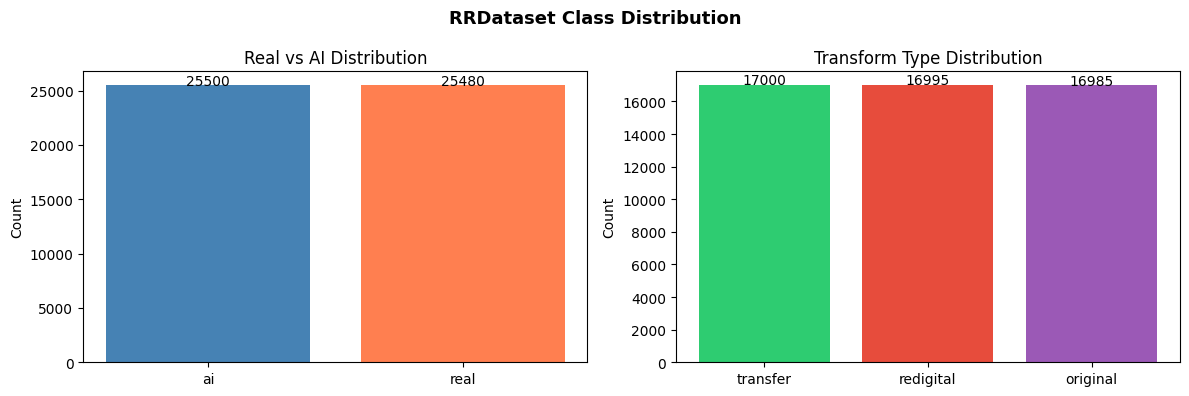

In [ ]:
# PHASE 3 - checking class distribution before training
# class distribution plot
inv_df = pd.read_csv('splits/inventory.csv')

rf_counts = inv_df['realfake'].value_counts()
tr_counts = inv_df['transform'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(rf_counts.index, rf_counts.values, color=['steelblue', 'coral'])
axes[0].set_title('Real vs AI Distribution')
axes[0].set_ylabel('Count')
for i in range(len(rf_counts)):
    val = rf_counts.values[i]
    axes[0].text(i, val + 50, str(val), ha='center')

axes[1].bar(tr_counts.index, tr_counts.values, color=['#2ecc71', '#e74c3c', '#9b59b6'])
axes[1].set_title('Transform Type Distribution')
axes[1].set_ylabel('Count')
for i in range(len(tr_counts)):
    val = tr_counts.values[i]
    axes[1].text(i, val + 50, str(val), ha='center')

plt.suptitle('RRDataset Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

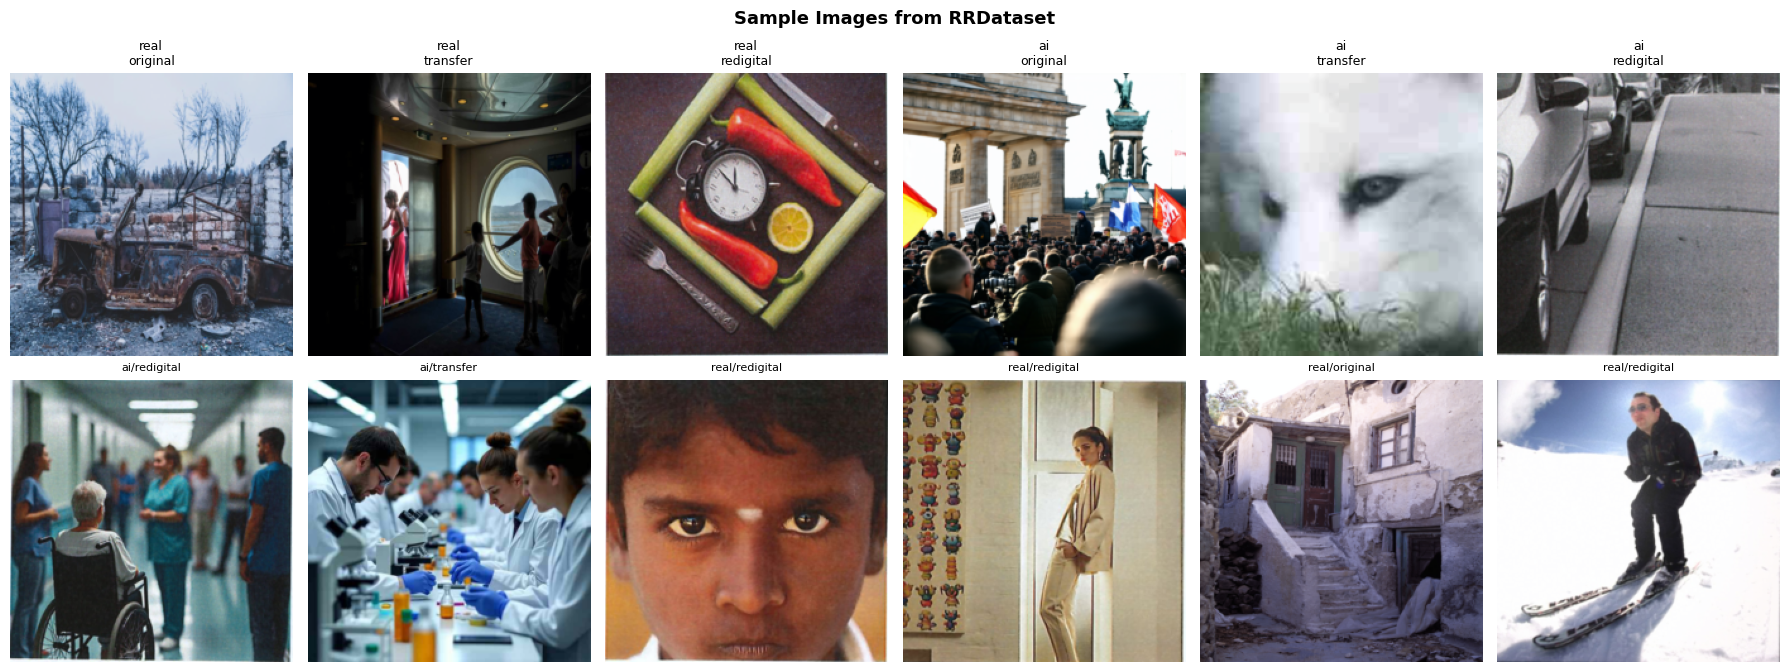

In [ ]:
# just checking a few images manually before moving ahead
# sample images
norm_mean = np.array([0.485, 0.456, 0.406])
norm_std = np.array([0.229, 0.224, 0.225])

sample_ds = RRDataset('splits/train.csv', transform=get_eval_transforms())

fig, axes = plt.subplots(2, 6, figsize=(18, 7))

shown_combinations = {}
col = 0
i = 0

while col < 6 and i < len(sample_ds):
    img, y_rf, y_tr = sample_ds[i]
    key = (int(y_rf), int(y_tr))

    if key not in shown_combinations:
        shown_combinations[key] = True
        img_arr = img.permute(1, 2, 0).numpy()
        img_arr = img_arr * norm_std + norm_mean
        img_arr = img_arr.clip(0, 1)

        axes[0, col].imshow(img_arr)
        title = f"{REALFAKE_NAMES[key[0]]}\n{TRANSFORM_NAMES[key[1]]}"
        axes[0, col].set_title(title, fontsize=9)
        axes[0, col].axis('off')
        col = col + 1

    i = i + 1

random_indices = np.random.choice(len(sample_ds), 6, replace=False)

for c in range(len(random_indices)):
    idx = random_indices[c]
    img, y_rf, y_tr = sample_ds[idx]
    img_arr = img.permute(1, 2, 0).numpy()
    img_arr = img_arr * norm_std + norm_mean
    img_arr = img_arr.clip(0, 1)

    axes[1, c].imshow(img_arr)
    title = f"{REALFAKE_NAMES[int(y_rf)]}/{TRANSFORM_NAMES[int(y_tr)]}"
    axes[1, c].set_title(title, fontsize=8)
    axes[1, c].axis('off')

plt.suptitle('Sample Images from RRDataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# model part - kept the logic explicit so I can follow both heads easily
# multi-task network
class MultiTaskNet(nn.Module):

    def __init__(self, backbone_name, num_rf=2, num_tr=3, multitask=True, pretrained=True):
        super().__init__()
        self.multitask = multitask
        self.backbone_name = backbone_name
        self.is_hf_vit = backbone_name in {
            'google/vit-base-patch16-224',
            'google_vit_base_patch16_224',
        }

        if self.is_hf_vit:
            if AutoModel is None:
                raise ImportError(
                    "transformers is required for Google ViT. "
                    "Run the install cell first or switch BACKBONE_VIT to 'vit_small_patch16_224'."
                )
            hf_name = 'google/vit-base-patch16-224'
            self.backbone = AutoModel.from_pretrained(hf_name)
            feat_dim = self.backbone.config.hidden_size
        else:
            self.backbone = timm.create_model(
                backbone_name,
                pretrained=pretrained,
                num_classes=0,
                global_pool='avg',
            )
            feat_dim = self.backbone.num_features

        self.fc_rf = nn.Linear(feat_dim, num_rf)
        self.fc_tr = nn.Linear(feat_dim, num_tr)

        # Backward-compatible aliases for earlier notebook cells.
        self.head_rf = self.fc_rf
        self.head_tr = self.fc_tr

    def extract_features(self, x):
        if self.is_hf_vit:
            # HuggingFace ViT returns hidden states. The [CLS] token is index 0.
            return self.backbone(pixel_values=x).last_hidden_state[:, 0]
        return self.backbone(x)

    def forward(self, x):
        features = self.extract_features(x)
        rf_logits = self.fc_rf(features)

        if self.multitask:
            tr_logits = self.fc_tr(features)
            return rf_logits, tr_logits
        return rf_logits


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


for backbone in [BACKBONE_CNN, BACKBONE_VIT]:
    try:
        m = MultiTaskNet(backbone, multitask=True)
        total_p = count_parameters(m)
        print(f"{backbone}: {total_p / 1e6:.1f}M trainable params")
        del m
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception as e:
        print(f"Could not initialize {backbone}: {e}")


resnet50: 23.5M trainable params


Unexpected keys (norm.bias, norm.weight) found while loading pretrained weights. This may be expected if model is being adapted.


vit_small_patch16_224: 21.7M trainable params


## Model Choice Update: ResNet Baseline + ViT Main Model

The project keeps **ResNet50** only as a simple baseline. The main model is now the **Google Vision Transformer**, adapted into a multi-task detector with two heads:

- `fc_rf`: real/fake binary classification
- `fc_tr`: original / internet-transmitted / re-digitized classification

This is stronger than a plain ResNet because self-attention compares image patches globally. That is useful for forensic detection, where AI-generation traces and post-processing artifacts may appear as subtle inconsistencies across texture, frequency, and spatial regions.


In [ ]:
# second part: preparing loaders for the main experiment
print('debug: preparing main experiment functions')
# Recommended main experiment: Google ViT + Kendall uncertainty multi-task loss

def build_loaders_for_main_experiment():
    if LOCAL_DEBUG:
        batch_size = DEBUG_BATCH_SIZE
        n_workers = 0
    else:
        # Google ViT is heavier than ResNet. Keep batch size conservative.
        batch_size = min(BATCH_SIZE, 32)
        n_workers = NUM_WORKERS

    train_ds_full = RRDataset('splits/train.csv', transform=get_train_transforms())
    val_ds_full = RRDataset('splits/val.csv', transform=get_eval_transforms())
    test_ds_full = RRDataset('splits/test.csv', transform=get_eval_transforms())

    if LOCAL_DEBUG:
        train_ds = make_subset(train_ds_full, DEBUG_SUBSET_SIZE)
        val_ds = make_subset(val_ds_full, DEBUG_SUBSET_SIZE // 4)
        test_ds = make_subset(test_ds_full, DEBUG_SUBSET_SIZE // 4)
    else:
        train_ds, val_ds, test_ds = train_ds_full, val_ds_full, test_ds_full

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=n_workers, pin_memory=torch.cuda.is_available())
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=n_workers, pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=n_workers, pin_memory=torch.cuda.is_available())
    return train_loader, val_loader, test_loader


# Uncomment for the final main run:
# LOCAL_DEBUG = False
# NUM_EPOCHS = 5
# train_loader, val_loader, test_loader = build_loaders_for_main_experiment()
# model = MultiTaskNet(BACKBONE_VIT, multitask=True).to(DEVICE)
# model, history_df, kendall_loss = train_model(
#     model,
#     train_loader,
#     val_loader,
#     epochs=NUM_EPOCHS,
#     device=DEVICE,
#     lr=5e-5,
#     checkpoint_path='results/checkpoints/google_vit_kendall_best.pt',
# )
# display(history_df)
#
# breakdown_df, y_rf_true, y_rf_pred, y_tr_true, y_tr_pred = generate_breakdown_table(model, test_loader, DEVICE)
# display(breakdown_df)
# cm_rf, cm_tr = plot_multitask_confusion_matrices(y_rf_true, y_rf_pred, y_tr_true, y_tr_pred)


debug: preparing main experiment functions


## SECTION 6: Multi-Task Training Loop with Kendall Uncertainty Weighting

This section trains the shared-backbone multi-task detector using the homoscedastic uncertainty weighting proposed by Kendall et al. (2018). The two learnable log-variance parameters, `s1` and `s2`, automatically control the contribution of the real/fake and transformation losses during training.


In [ ]:
# second part: uncertainty weighted training
print('debug: loading uncertainty-loss training section')
# SECTION 6: MULTI-TASK TRAINING LOOP (KENDALL UNCERTAINTY WEIGHTING)

class UncertaintyWeightedLoss(nn.Module):

    def __init__(self):
        super().__init__()
        self.s1 = nn.Parameter(torch.tensor(0.0))
        self.s2 = nn.Parameter(torch.tensor(0.0))
        self.ce_rf = nn.CrossEntropyLoss()
        self.ce_tr = nn.CrossEntropyLoss()

    def forward(self, rf_logits, tr_logits, y_rf, y_tr):
        loss_rf = self.ce_rf(rf_logits, y_rf)
        loss_tr = self.ce_tr(tr_logits, y_tr)

        weighted_rf = torch.exp(-self.s1) * loss_rf + self.s1
        weighted_tr = torch.exp(-self.s2) * loss_tr + self.s2
        total_loss = weighted_rf + weighted_tr

        return total_loss, loss_rf, loss_tr


def _unpack_batch(batch, device):

    if len(batch) != 3:
        raise ValueError(
            "Expected each batch to contain exactly (images, y_rf, y_tr). "
            f"Received {len(batch)} elements."
        )

    images, y_rf, y_tr = batch
    images = images.to(device, non_blocking=True)
    y_rf = y_rf.to(device, non_blocking=True).long()
    y_tr = y_tr.to(device, non_blocking=True).long()
    return images, y_rf, y_tr


def _forward_multitask(model, images):

    outputs = model(images)
    if not isinstance(outputs, (tuple, list)) or len(outputs) != 2:
        raise ValueError(
            "The multi-task model must return (rf_logits, tr_logits). "
            "Instantiate the model in multi-task mode before training."
        )
    return outputs[0], outputs[1]


def train_model(
    model,
    train_loader,
    val_loader,
    epochs,
    device,
    lr=1e-4,
    weight_decay=1e-4,
    max_grad_norm=1.0,
    checkpoint_path="results/checkpoints/best_kendall_multitask.pt",
):

    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

    device = torch.device(device)
    model = model.to(device)
    criterion = UncertaintyWeightedLoss().to(device)

    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(criterion.parameters()),
        lr=lr,
        weight_decay=weight_decay,
    )

    use_amp = device.type == "cuda"
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    best_val_score = -1.0
    best_state = None
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        criterion.train()

        train_total = 0.0
        train_rf = 0.0
        train_tr = 0.0
        train_n = 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [train]", leave=False):
            images, y_rf, y_tr = _unpack_batch(batch, device)
            batch_size = images.size(0)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda', enabled=use_amp):
                rf_logits, tr_logits = _forward_multitask(model, images)
                loss, loss_rf, loss_tr = criterion(rf_logits, tr_logits, y_rf, y_tr)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                list(model.parameters()) + list(criterion.parameters()),
                max_grad_norm,
            )
            scaler.step(optimizer)
            scaler.update()

            train_total += loss.item() * batch_size
            train_rf += loss_rf.item() * batch_size
            train_tr += loss_tr.item() * batch_size
            train_n += batch_size

        train_total /= max(train_n, 1)
        train_rf /= max(train_n, 1)
        train_tr /= max(train_n, 1)

        model.eval()
        criterion.eval()

        val_total = 0.0
        val_rf = 0.0
        val_tr = 0.0
        val_n = 0
        rf_correct = 0
        tr_correct = 0

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{epochs} [val]", leave=False):
                images, y_rf, y_tr = _unpack_batch(batch, device)
                batch_size = images.size(0)

                with torch.amp.autocast('cuda', enabled=use_amp):
                    rf_logits, tr_logits = _forward_multitask(model, images)
                    loss, loss_rf, loss_tr = criterion(rf_logits, tr_logits, y_rf, y_tr)

                rf_pred = rf_logits.argmax(dim=1)
                tr_pred = tr_logits.argmax(dim=1)

                rf_correct += (rf_pred == y_rf).sum().item()
                tr_correct += (tr_pred == y_tr).sum().item()
                val_total += loss.item() * batch_size
                val_rf += loss_rf.item() * batch_size
                val_tr += loss_tr.item() * batch_size
                val_n += batch_size

        val_total /= max(val_n, 1)
        val_rf /= max(val_n, 1)
        val_tr /= max(val_n, 1)
        val_rf_acc = rf_correct / max(val_n, 1)
        val_tr_acc = tr_correct / max(val_n, 1)
        val_score = 0.5 * (val_rf_acc + val_tr_acc)

        row = {
            "epoch": epoch,
            "train_loss": train_total,
            "train_rf_loss": train_rf,
            "train_tr_loss": train_tr,
            "val_loss": val_total,
            "val_rf_loss": val_rf,
            "val_tr_loss": val_tr,
            "val_rf_acc": val_rf_acc,
            "val_tr_acc": val_tr_acc,
            "s1": criterion.s1.item(),
            "s2": criterion.s2.item(),
        }
        history.append(row)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss={train_total:.4f} rf={train_rf:.4f} tr={train_tr:.4f} | "
            f"val loss={val_total:.4f} rf={val_rf:.4f} tr={val_tr:.4f} | "
            f"val rf_acc={val_rf_acc:.4f} tr_acc={val_tr_acc:.4f} | "
            f"s1={criterion.s1.item():+.4f} s2={criterion.s2.item():+.4f}"
        )

        if val_score > best_val_score:
            best_val_score = val_score
            best_state = {
                "model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
                "criterion": {k: v.detach().cpu().clone() for k, v in criterion.state_dict().items()},
                "epoch": epoch,
                "val_score": val_score,
            }
            torch.save(best_state, checkpoint_path)

    if best_state is not None:
        model.load_state_dict(best_state["model"])
        criterion.load_state_dict(best_state["criterion"])

    history_df = pd.DataFrame(history)
    return model, history_df, criterion


debug: loading uncertainty-loss training section


## SECTION 7: Evaluation and Detailed Cross-Class Breakdown

This section evaluates the final multi-task model on the test set. It reports how well the real/fake head works inside each post-processing category and plots both confusion matrices.


In [ ]:
# second part: detailed evaluation
print('debug: loading detailed evaluation helpers')
# SECTION 7: EVALUATION AND DETAILED CROSS-CLASS BREAKDOWN

RF_CLASS_NAMES = ["Real", "Fake"]
TR_CLASS_NAMES = ["Original", "Internet-Transmitted", "Re-digitized"]


def _safe_accuracy(correct, total):
    if total > 0:
        answer = float(correct) / float(total)
    else:
        answer = np.nan
    return answer


def generate_breakdown_table(model, test_loader, device):

    device = torch.device(device)
    model = model.to(device)
    model.eval()

    y_rf_true = []
    y_rf_pred = []
    y_tr_true = []
    y_tr_pred = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating test set", leave=False):
            images, y_rf, y_tr = _unpack_batch(batch, device)
            rf_logits, tr_logits = _forward_multitask(model, images)

            rf_pred = rf_logits.argmax(dim=1)
            tr_pred = tr_logits.argmax(dim=1)

            y_rf_true.extend(y_rf.cpu().numpy().tolist())
            y_rf_pred.extend(rf_pred.cpu().numpy().tolist())
            y_tr_true.extend(y_tr.cpu().numpy().tolist())
            y_tr_pred.extend(tr_pred.cpu().numpy().tolist())

    y_rf_true = np.asarray(y_rf_true)
    y_rf_pred = np.asarray(y_rf_pred)
    y_tr_true = np.asarray(y_tr_true)
    y_tr_pred = np.asarray(y_tr_pred)

    rows = []
    for tr_idx, tr_name in enumerate(TR_CLASS_NAMES):
        tr_mask = y_tr_true == tr_idx

        overall_correct = np.sum(y_rf_pred[tr_mask] == y_rf_true[tr_mask])
        overall_total = np.sum(tr_mask)

        real_mask = tr_mask & (y_rf_true == 0)
        fake_mask = tr_mask & (y_rf_true == 1)

        real_correct = np.sum(y_rf_pred[real_mask] == y_rf_true[real_mask])
        fake_correct = np.sum(y_rf_pred[fake_mask] == y_rf_true[fake_mask])

        rows.append({
            "Transformation Name": tr_name,
            "Overall Real/Fake Accuracy": _safe_accuracy(overall_correct, overall_total),
            "Real Image Accuracy": _safe_accuracy(real_correct, np.sum(real_mask)),
            "Fake Image Accuracy": _safe_accuracy(fake_correct, np.sum(fake_mask)),
        })

    breakdown_df = pd.DataFrame(rows)
    return breakdown_df, y_rf_true, y_rf_pred, y_tr_true, y_tr_pred


def _confusion_matrix_numpy(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for true_label, pred_label in zip(y_true, y_pred):
        if 0 <= int(true_label) < num_classes and 0 <= int(pred_label) < num_classes:
            cm[int(true_label), int(pred_label)] += 1
    return cm


def plot_multitask_confusion_matrices(y_rf_true, y_rf_pred, y_tr_true, y_tr_pred):

    cm_rf = _confusion_matrix_numpy(y_rf_true, y_rf_pred, num_classes=2)
    cm_tr = _confusion_matrix_numpy(y_tr_true, y_tr_pred, num_classes=3)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        cm_rf,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=RF_CLASS_NAMES,
        yticklabels=RF_CLASS_NAMES,
        ax=axes[0],
    )
    axes[0].set_title("Real/Fake Confusion Matrix")
    axes[0].set_xlabel("Predicted label")
    axes[0].set_ylabel("True label")

    sns.heatmap(
        cm_tr,
        annot=True,
        fmt="d",
        cmap="Greens",
        xticklabels=TR_CLASS_NAMES,
        yticklabels=TR_CLASS_NAMES,
        ax=axes[1],
    )
    axes[1].set_title("Transformation Confusion Matrix")
    axes[1].set_xlabel("Predicted label")
    axes[1].set_ylabel("True label")

    plt.tight_layout()
    plt.show()

    return cm_rf, cm_tr




debug: loading detailed evaluation helpers


In [ ]:
# extra loss functions used for the comparison runs
# losses
class WeightedCELoss(nn.Module):
    def __init__(self, w_rf=0.5, w_tr=0.5):
        super().__init__()
        self.w_rf = w_rf
        self.w_tr = w_tr
        self.ce = nn.CrossEntropyLoss()

    def forward(self, rf_logits, tr_logits, y_rf, y_tr):
        loss_rf = self.ce(rf_logits, y_rf)
        loss_tr = self.ce(tr_logits, y_tr)
        rf_part = self.w_rf * loss_rf
        tr_part = self.w_tr * loss_tr
        total = rf_part + tr_part
        return total, loss_rf, loss_tr


class UncertaintyWeightedLoss(nn.Module):

    def __init__(self):
        super().__init__()
        self.s1 = nn.Parameter(torch.tensor(0.0))
        self.s2 = nn.Parameter(torch.tensor(0.0))
        self.ce_rf = nn.CrossEntropyLoss()
        self.ce_tr = nn.CrossEntropyLoss()

    def forward(self, rf_logits, tr_logits, y_rf, y_tr):
        loss_rf = self.ce_rf(rf_logits, y_rf)
        loss_tr = self.ce_tr(tr_logits, y_tr)
        total = torch.exp(-self.s1) * loss_rf + self.s1
        total = total + torch.exp(-self.s2) * loss_tr + self.s2
        return total, loss_rf, loss_tr


In [ ]:
# training/evaluation loop - written step by step for easier debugging
# train loop
def evaluate_loop(model, loader, device, multitask=True):
    model.eval()

    rf_preds_all = []
    rf_labels_all = []
    tr_preds_all = []
    tr_labels_all = []

    with torch.no_grad():
        for images, y_rf, y_tr in loader:
            images = images.to(device)
            y_rf = y_rf.to(device)
            y_tr = y_tr.to(device)

            if multitask:
                rf_logits, tr_logits = model(images)
                tr_preds = tr_logits.argmax(dim=1).cpu().numpy()
                tr_preds_all.extend(tr_preds)
                tr_labels_all.extend(y_tr.cpu().numpy())
            else:
                rf_logits = model(images)

            rf_preds = rf_logits.argmax(dim=1).cpu().numpy()
            rf_preds_all.extend(rf_preds)
            rf_labels_all.extend(y_rf.cpu().numpy())

    rf_preds_arr = np.array(rf_preds_all)
    rf_labels_arr = np.array(rf_labels_all)

    metrics = {}
    metrics['rf_acc'] = (rf_preds_arr == rf_labels_arr).mean()
    metrics['rf_f1'] = f1_score(rf_labels_arr, rf_preds_arr, average='macro', zero_division=0)

    if multitask:
        tr_preds_arr = np.array(tr_preds_all)
        tr_labels_arr = np.array(tr_labels_all)
        metrics['tr_acc'] = (tr_preds_arr == tr_labels_arr).mean()
        metrics['tr_f1'] = f1_score(tr_labels_arr, tr_preds_arr, average='macro', zero_division=0)

    return metrics


def train_one_run(run_name, backbone_name, multitask=True, loss_fn=None, use_wandb=False):
    set_seed()
    device = DEVICE

    if LOCAL_DEBUG:
        epochs = DEBUG_EPOCHS
        batch_size = DEBUG_BATCH_SIZE
        n_workers = 0
    else:
        epochs = NUM_EPOCHS
        batch_size = BATCH_SIZE
        n_workers = NUM_WORKERS

    if 'vit' in backbone_name:
        lr = 5e-5
    else:
        lr = LEARNING_RATE

    print(f"\n>>> {run_name} | backbone={backbone_name} | mt={multitask}")

    train_ds_full = RRDataset('splits/train.csv', transform=get_train_transforms())
    val_ds_full = RRDataset('splits/val.csv', transform=get_eval_transforms())

    if LOCAL_DEBUG:
        train_ds = make_subset(train_ds_full, DEBUG_SUBSET_SIZE)
        val_ds = make_subset(val_ds_full, DEBUG_SUBSET_SIZE // 4)
    else:
        train_ds = train_ds_full
        val_ds = val_ds_full

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=n_workers)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=n_workers)

    model = MultiTaskNet(backbone_name, multitask=multitask).to(device)
    if loss_fn is not None and hasattr(loss_fn, 'to'):
        loss_fn = loss_fn.to(device)

    params = list(model.parameters())
    if isinstance(loss_fn, UncertaintyWeightedLoss):
        params = params + list(loss_fn.parameters())

    optimizer = AdamW(params, lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    ce_loss = nn.CrossEntropyLoss()

    use_amp = (device.type == 'cuda')
    if use_amp:
        scaler = torch.amp.GradScaler(enabled=True)
    else:
        scaler = None

    if use_wandb:
        try:
            import wandb
            wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name=run_name, reinit=True)
        except ImportError:
            use_wandb = False

    os.makedirs('results/checkpoints', exist_ok=True)

    best_rf_acc = 0.0
    best_metrics = {}

    for epoch in range(1, epochs + 1):
        model.train()
        if isinstance(loss_fn, UncertaintyWeightedLoss):
            loss_fn.train()

        running_loss = 0.0
        n_batches = 0

        pbar = tqdm(train_loader, desc=f"ep {epoch}/{epochs}", leave=False)
        for images, y_rf, y_tr in pbar:
            images = images.to(device)
            y_rf = y_rf.to(device)
            y_tr = y_tr.to(device)

            optimizer.zero_grad()

            if use_amp:
                with torch.autocast(device_type='cuda'):
                    if multitask:
                        rf_logits, tr_logits = model(images)
                        loss, l_rf, l_tr = loss_fn(rf_logits, tr_logits, y_rf, y_tr)
                    else:
                        rf_logits = model(images)
                        loss = ce_loss(rf_logits, y_rf)

                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(params, MAX_GRAD_NORM)
                scaler.step(optimizer)
                scaler.update()
            else:
                if multitask:
                    rf_logits, tr_logits = model(images)
                    loss, l_rf, l_tr = loss_fn(rf_logits, tr_logits, y_rf, y_tr)
                else:
                    rf_logits = model(images)
                    loss = ce_loss(rf_logits, y_rf)

                loss.backward()
                torch.nn.utils.clip_grad_norm_(params, MAX_GRAD_NORM)
                optimizer.step()

            running_loss = running_loss + loss.item()
            n_batches = n_batches + 1

        scheduler.step()
        avg_loss = running_loss / n_batches

        metrics = evaluate_loop(model, val_loader, device, multitask=multitask)
        rf_acc = metrics['rf_acc']

        log_msg = f"ep {epoch}/{epochs} | loss={avg_loss:.4f} | rf_acc={rf_acc:.4f}"
        if multitask:
            log_msg = log_msg + f" | tr_acc={metrics.get('tr_acc', 0):.4f}"
        print(log_msg)

        if use_wandb:
            import wandb
            log_dict = {'epoch': epoch, 'loss': avg_loss}
            for k in metrics:
                log_dict[k] = metrics[k]
            wandb.log(log_dict)

        if rf_acc > best_rf_acc:
            best_rf_acc = rf_acc
            best_metrics = metrics.copy()
            ckpt_path = f"results/checkpoints/{run_name}_best.pt"
            torch.save(model.state_dict(), ckpt_path)

    if use_wandb:
        import wandb
        wandb.finish()

    return best_metrics


In [ ]:
# baseline experiments
print('debug: baseline runner ready')
# baselines
def run_baselines(use_wandb=False):
    results = []

    configs = [
        ('resnet50_rf', BACKBONE_CNN, False, None, 'realfake'),
        ('resnet50_tr', BACKBONE_CNN, True, WeightedCELoss(0.0, 1.0), 'transform'),
        ('vit_rf', BACKBONE_VIT, False, None, 'realfake'),
        ('vit_tr', BACKBONE_VIT, True, WeightedCELoss(0.0, 1.0), 'transform'),
    ]

    for run_name, backbone, multitask, loss_fn, task in configs:
        metrics = train_one_run(
            run_name=run_name,
            backbone_name=backbone,
            multitask=multitask,
            loss_fn=loss_fn,
            use_wandb=use_wandb,
        )

        row = {
            'backbone': backbone,
            'task': task,
            'rf_acc': round(float(metrics.get('rf_acc', 0)), 4),
            'rf_f1': round(float(metrics.get('rf_f1', 0)), 4),
            'tr_acc': round(float(metrics.get('tr_acc', 0)), 4),
            'tr_f1': round(float(metrics.get('tr_f1', 0)), 4),
        }
        results.append(row)

    df_res = pd.DataFrame(results)
    df_res.to_csv('results/baselines.csv', index=False)
    return results


baseline_results = run_baselines(use_wandb=False)

debug: baseline runner ready

>>> resnet50_rf | backbone=resnet50 | mt=False


ep 1/3 | loss=0.6812 | rf_acc=0.5267


ep 2/3 | loss=0.6442 | rf_acc=0.6067


ep 3/3 | loss=0.6227 | rf_acc=0.6200

>>> resnet50_tr | backbone=resnet50 | mt=True


ep 1/3 | loss=1.0941 | rf_acc=0.4600 | tr_acc=0.3733


...

ep 3/3 | loss=0.0610 | rf_acc=0.8200

>>> vit_tr | backbone=vit_small_patch16_224 | mt=True


Unexpected keys (norm.bias, norm.weight) found while loading pretrained weights. This may be expected if model is being adapted.


ep 1/3 | loss=1.1150 | rf_acc=0.5067 | tr_acc=0.4800


ep 2/3 | loss=0.8209 | rf_acc=0.4800 | tr_acc=0.5200


ep 3/3 | loss=0.5486 | rf_acc=0.4933 | tr_acc=0.5800


In [ ]:
# show baselines
pd.read_csv('results/baselines.csv')

,backbone,task,rf_acc,rf_f1,tr_acc,tr_f1
0,resnet50,realfake,0.6200,0.5786,0.0000,0.0000
1,resnet50,transform,0.5200,0.5113,0.4067,0.3883
2,vit_small_patch16_224,realfake,0.8200,0.8193,0.0000,0.0000
3,vit_small_patch16_224,transform,0.5067,0.4504,0.4800,0.4676


In [ ]:
# multi-task experiments with different weight combinations
# multi-task experiments
def run_multitask(backbone_name=None, use_wandb=False):
    if backbone_name is None:
        selected_backbone = BACKBONE_VIT
    else:
        selected_backbone = backbone_name

    backbone_name = selected_backbone

    experiments = [
        ('multitask_A_rf_only', 1.0, 0.0, False),
        ('multitask_B_tr_only', 0.0, 1.0, False),
        ('multitask_C_equal', 0.5, 0.5, False),
        ('multitask_D_rf_heavy', 0.7, 0.3, False),
        ('multitask_E_tr_heavy', 0.3, 0.7, False),
        ('multitask_F_uncertainty', None, None, True),
    ]

    results = []

    for run_name, w_rf, w_tr, use_uncertainty in experiments:
        if use_uncertainty:
            loss_fn = UncertaintyWeightedLoss()
        else:
            loss_fn = WeightedCELoss(w_rf=w_rf, w_tr=w_tr)

        metrics = train_one_run(
            run_name=run_name,
            backbone_name=backbone_name,
            multitask=True,
            loss_fn=loss_fn,
            use_wandb=use_wandb,
        )

        if use_uncertainty:
            w_rf_out = 'learned'
            w_tr_out = 'learned'
        else:
            w_rf_out = w_rf
            w_tr_out = w_tr

        row = {
            'run': run_name,
            'backbone': backbone_name,
            'w_rf': w_rf_out,
            'w_tr': w_tr_out,
            'rf_acc': round(float(metrics.get('rf_acc', 0)), 4),
            'rf_f1': round(float(metrics.get('rf_f1', 0)), 4),
            'tr_acc': round(float(metrics.get('tr_acc', 0)), 4),
            'tr_f1': round(float(metrics.get('tr_f1', 0)), 4),
        }
        results.append(row)

    df_res = pd.DataFrame(results)
    df_res.to_csv('results/multitask.csv', index=False)
    return results


multitask_results = run_multitask(use_wandb=False)


>>> multitask_A_rf_only | backbone=vit_small_patch16_224 | mt=True


Unexpected keys (norm.bias, norm.weight) found while loading pretrained weights. This may be expected if model is being adapted.


ep 1/3 | loss=0.4649 | rf_acc=0.7200 | tr_acc=0.3667


ep 2/3 | loss=0.1901 | rf_acc=0.7800 | tr_acc=0.3533


ep 3/3 | loss=0.0610 | rf_acc=0.8200 | tr_acc=0.3400

>>> multitask_B_tr_only | backbone=vit_small_patch16_224 | mt=True


...

ep 3/3 | loss=0.4825 | rf_acc=0.7400 | tr_acc=0.5800

>>> multitask_F_uncertainty | backbone=vit_small_patch16_224 | mt=True


Unexpected keys (norm.bias, norm.weight) found while loading pretrained weights. This may be expected if model is being adapted.


ep 1/3 | loss=1.6466 | rf_acc=0.7000 | tr_acc=0.4000


ep 2/3 | loss=1.1309 | rf_acc=0.7933 | tr_acc=0.4400


ep 3/3 | loss=0.7766 | rf_acc=0.8067 | tr_acc=0.5067


In [ ]:
# show multitask
pd.read_csv('results/multitask.csv')

,run,backbone,w_rf,w_tr,rf_acc,rf_f1,tr_acc,tr_f1
0,multitask_A_rf_only,vit_small_patch16_224,1.0,0.0,0.8200,0.8193,0.3400,0.2820
1,multitask_B_tr_only,vit_small_patch16_224,0.0,1.0,0.5067,0.4504,0.4800,0.4676
2,multitask_C_equal,vit_small_patch16_224,0.5,0.5,0.8200,0.8199,0.5000,0.4994
3,multitask_D_rf_heavy,vit_small_patch16_224,0.7,0.3,0.7800,0.7792,0.4400,0.4297
4,multitask_E_tr_heavy,vit_small_patch16_224,0.3,0.7,0.7600,0.7596,0.4933,0.4682
5,multitask_F_uncertainty,vit_small_patch16_224,learned,learned,0.8067,0.8065,0.5067,0.5081


In [ ]:
# final model evaluation
print('debug: final evaluation function ready')
# evaluate best model
def evaluate_model(model, test_csv, run_name, multitask=True):
    if LOCAL_DEBUG:
        batch_size = DEBUG_BATCH_SIZE
        n_workers = 0
    else:
        batch_size = BATCH_SIZE
        n_workers = NUM_WORKERS

    test_ds = RRDataset(test_csv, transform=get_eval_transforms())

    if LOCAL_DEBUG:
        test_ds = make_subset(test_ds, DEBUG_SUBSET_SIZE // 2)

    loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=n_workers)

    model.eval()
    records = []

    with torch.no_grad():
        for images, y_rf, y_tr in loader:
            images = images.to(DEVICE)

            if multitask:
                rf_logits, tr_logits = model(images)
                tr_preds = tr_logits.argmax(dim=1).cpu().numpy()
            else:
                rf_logits = model(images)
                tr_preds = [-1] * len(y_rf)

            rf_preds = rf_logits.argmax(dim=1).cpu().numpy()

            for i in range(len(y_rf)):
                rec = {
                    'y_rf': int(y_rf[i]),
                    'y_tr': int(y_tr[i]),
                    'pred_rf': int(rf_preds[i]),
                    'pred_tr': int(tr_preds[i]) if multitask else -1,
                }
                records.append(rec)

    df = pd.DataFrame(records)

    rf_acc = (df['pred_rf'] == df['y_rf']).mean()
    rf_f1 = f1_score(df['y_rf'], df['pred_rf'], average='macro', zero_division=0)
    print(f"realfake: acc={rf_acc:.4f}, f1={rf_f1:.4f}")

    if multitask:
        tr_acc = (df['pred_tr'] == df['y_tr']).mean()
        tr_f1 = f1_score(df['y_tr'], df['pred_tr'], average='macro', zero_division=0)
        print(f"transform: acc={tr_acc:.4f}, f1={tr_f1:.4f}")

    breakdown_rows = []

    for tr_label in TRANSFORM_NAMES:
        tr_name = TRANSFORM_NAMES[tr_label]
        sub = df[df['y_tr'] == tr_label]

        if len(sub) == 0:
            continue

        for rf_label in REALFAKE_NAMES:
            rf_name = REALFAKE_NAMES[rf_label]
            cell_df = sub[sub['y_rf'] == rf_label]

            if len(cell_df) == 0:
                continue

            cell_acc = (cell_df['pred_rf'] == cell_df['y_rf']).mean()
            cell_f1 = f1_score(cell_df['y_rf'], cell_df['pred_rf'], average='macro', zero_division=0)

            row = {
                'transform': tr_name,
                'realfake': rf_name,
                'n': len(cell_df),
                'rf_acc': round(float(cell_acc), 4),
                'rf_f1': round(float(cell_f1), 4),
            }
            breakdown_rows.append(row)

    bd_path = f"results/breakdown_{run_name}.csv"
    pd.DataFrame(breakdown_rows).to_csv(bd_path, index=False)

    return df, breakdown_rows


BEST_RUN = 'multitask_D_rf_heavy'
BEST_BACKBONE = BACKBONE_VIT

best_model = MultiTaskNet(BEST_BACKBONE, multitask=True).to(DEVICE)
ckpt_path = f"results/checkpoints/{BEST_RUN}_best.pt"
if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}. Run cells 20 and 22 first.")
best_model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=False))

df_test, breakdown_rows = evaluate_model(best_model, 'splits/test.csv', BEST_RUN)

debug: final evaluation function ready


Unexpected keys (norm.bias, norm.weight) found while loading pretrained weights. This may be expected if model is being adapted.


realfake: acc=0.8367, f1=0.8357
transform: acc=0.4833, f1=0.4789


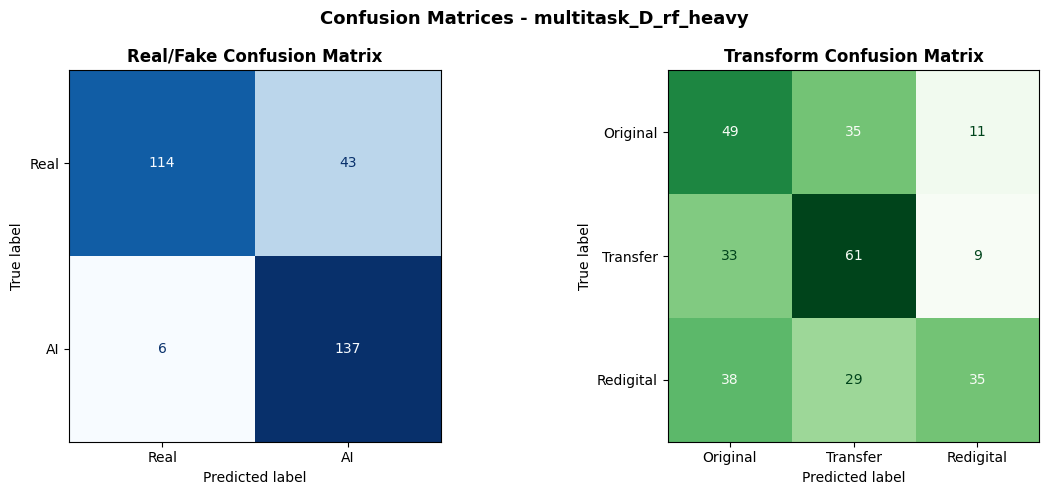

In [ ]:
# plotting both confusion matrices
# confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_rf = confusion_matrix(df_test['y_rf'], df_test['pred_rf'])
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=['Real', 'AI'])
disp_rf.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Real/Fake Confusion Matrix', fontweight='bold')

cm_tr = confusion_matrix(df_test['y_tr'], df_test['pred_tr'])
disp_tr = ConfusionMatrixDisplay(cm_tr, display_labels=['Original', 'Transfer', 'Redigital'])
disp_tr.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Transform Confusion Matrix', fontweight='bold')

plt.suptitle(f"Confusion Matrices - {BEST_RUN}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"results/confusion_matrices_{BEST_RUN}.png", dpi=120, bbox_inches='tight')
plt.show()

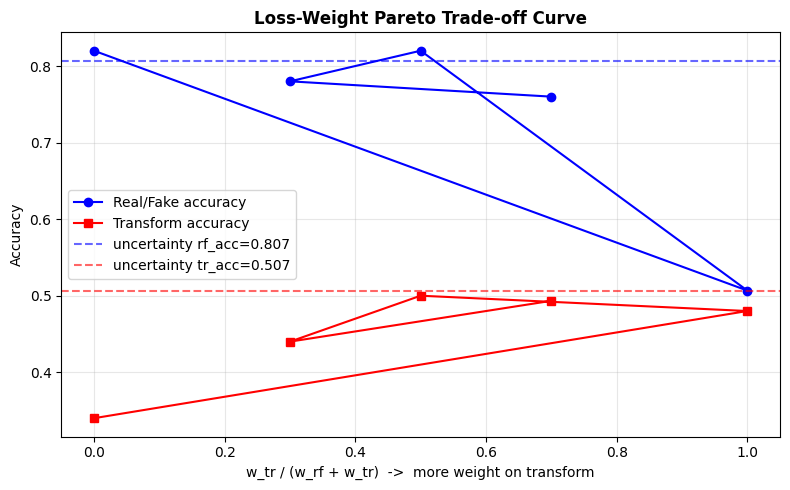

In [ ]:
# checking the trade-off between both tasks
# pareto plot
df_mt = pd.read_csv('results/multitask.csv')

df_pareto = df_mt[df_mt['w_rf'] != 'learned'].copy()
df_pareto['w_rf'] = df_pareto['w_rf'].astype(float)
df_pareto['w_tr'] = df_pareto['w_tr'].astype(float)
df_pareto['x_axis'] = df_pareto['w_tr'] / (df_pareto['w_rf'] + df_pareto['w_tr'] + 1e-9)

df_unc = df_mt[df_mt['w_rf'] == 'learned']

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(df_pareto['x_axis'], df_pareto['rf_acc'], 'b-o', label='Real/Fake accuracy')
ax.plot(df_pareto['x_axis'], df_pareto['tr_acc'], 'r-s', label='Transform accuracy')

if len(df_unc) > 0:
    unc_rf = float(df_unc['rf_acc'].iloc[0])
    unc_tr = float(df_unc['tr_acc'].iloc[0])
    ax.axhline(unc_rf, color='b', linestyle='--', alpha=0.6, label=f"uncertainty rf_acc={unc_rf:.3f}")
    ax.axhline(unc_tr, color='r', linestyle='--', alpha=0.6, label=f"uncertainty tr_acc={unc_tr:.3f}")

ax.set_xlabel('w_tr / (w_rf + w_tr)  ->  more weight on transform')
ax.set_ylabel('Accuracy')
ax.set_title('Loss-Weight Pareto Trade-off Curve', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/pareto_plot.png', dpi=120, bbox_inches='tight')
plt.show()

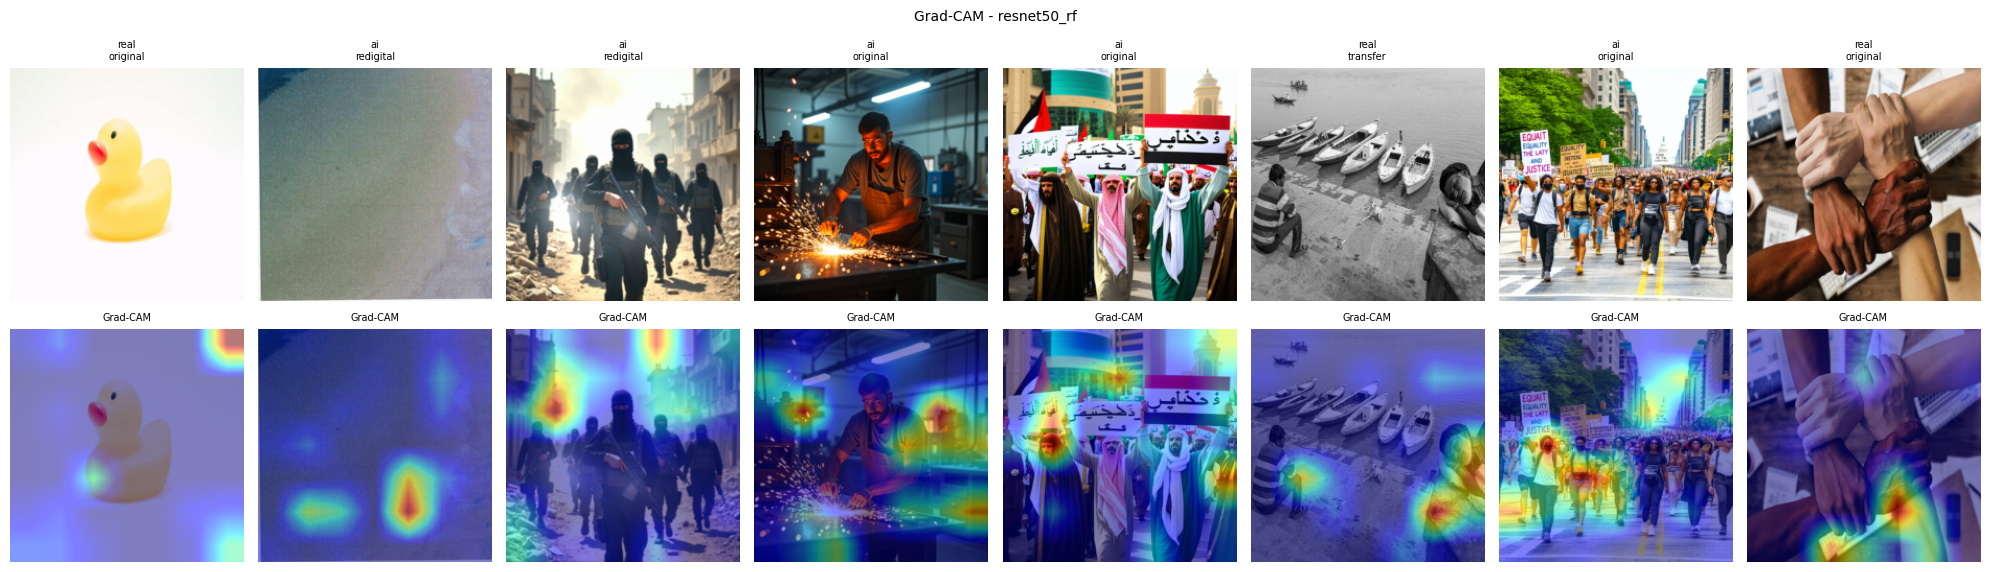

In [ ]:
# Grad-CAM helper used for visual checking
# grad-cam
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        def fwd_hook(module, inp, out):
            self.activations = out.detach()

        def bwd_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        target_layer.register_forward_hook(fwd_hook)
        target_layer.register_full_backward_hook(bwd_hook)

    def generate(self, inp, class_idx, head='rf'):
        self.model.zero_grad()
        inp = inp.clone().requires_grad_(True)

        out = self.model(inp)

        if isinstance(out, tuple):
            if head == 'rf':
                logits = out[0]
            else:
                logits = out[1]
        else:
            logits = out

        score = logits[0, class_idx]
        score.backward()

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1).squeeze()
        cam = torch.relu(cam).cpu().numpy()

        if cam.max() > 0:
            cam = cam / cam.max()
        return cam


def visualize_gradcam(model, test_csv, run_name, backbone_name, n_samples=8):
    if 'vit' in backbone_name:
        return

    target_layer = model.backbone.layer4[-1]
    gc = GradCAM(model, target_layer)
    model.to(DEVICE)

    ds = RRDataset(test_csv, transform=get_eval_transforms())
    n = min(n_samples, len(ds))
    indices = np.random.choice(len(ds), n, replace=False)

    norm_mean = np.array([0.485, 0.456, 0.406])
    norm_std = np.array([0.229, 0.224, 0.225])

    fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 2.5, 6))

    if hasattr(Image, 'Resampling'):
        resampling = Image.Resampling.BILINEAR
    else:
        resampling = Image.BILINEAR

    for col in range(len(indices)):
        idx = indices[col]
        img_t, y_rf, y_tr = ds[idx]
        inp = img_t.unsqueeze(0).to(DEVICE)

        img_arr = img_t.permute(1, 2, 0).numpy()
        img_arr = img_arr * norm_std + norm_mean
        img_arr = img_arr.clip(0, 1)

        cam = gc.generate(inp, int(y_rf), head='rf')
        cam_pil = Image.fromarray((cam * 255).astype(np.uint8))
        cam_resized = cam_pil.resize((img_arr.shape[1], img_arr.shape[0]), resampling)
        cam_resized = np.array(cam_resized) / 255.0

        axes[0, col].imshow(img_arr)
        title = f"{REALFAKE_NAMES[int(y_rf)]}\n{TRANSFORM_NAMES[int(y_tr)]}"
        axes[0, col].set_title(title, fontsize=7)
        axes[0, col].axis('off')

        axes[1, col].imshow(img_arr)
        axes[1, col].imshow(cam_resized, alpha=0.5, cmap='jet')
        axes[1, col].set_title('Grad-CAM', fontsize=7)
        axes[1, col].axis('off')

    plt.suptitle(f"Grad-CAM - {run_name}", fontsize=10)
    plt.tight_layout()

    os.makedirs('results/gradcam', exist_ok=True)
    out_path = f"results/gradcam/{run_name}.png"
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()


resnet_model = MultiTaskNet(BACKBONE_CNN, multitask=False).to(DEVICE)
resnet_ckpt = 'results/checkpoints/resnet50_rf_best.pt'
if not os.path.exists(resnet_ckpt):
    print(f'Skipping Grad-CAM: checkpoint not found at {resnet_ckpt}. Run cell 20 first.')
else:
    resnet_model.load_state_dict(torch.load(resnet_ckpt, map_location=DEVICE, weights_only=False))
    visualize_gradcam(resnet_model, 'splits/test.csv', 'resnet50_rf', BACKBONE_CNN, n_samples=8)

In [ ]:
# final cross-class check
# cross-class trace
df_bd = pd.DataFrame(breakdown_rows)

pivot = df_bd.pivot(index='transform', columns='realfake', values='rf_acc')
print(pivot)

for tr_name in df_bd['transform'].unique():
    sub = df_bd[df_bd['transform'] == tr_name]
    real_row = sub[sub['realfake'] == 'real']['rf_acc'].values
    ai_row = sub[sub['realfake'] == 'ai']['rf_acc'].values

    if len(real_row) > 0 and len(ai_row) > 0:
        real_acc = float(real_row[0])
        ai_acc = float(ai_row[0])
        delta = ai_acc - real_acc
        print(f"{tr_name}: real={real_acc:.3f}, ai={ai_acc:.3f}, delta={delta:+.3f}")

realfake       ai    real
transform                
original   0.9767  0.6154
redigital  0.9273  0.8298
transfer   0.9778  0.7414
original: real=0.615, ai=0.977, delta=+0.361
transfer: real=0.741, ai=0.978, delta=+0.236
redigital: real=0.830, ai=0.927, delta=+0.098
